In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

In [47]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])

train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform_test)

gpu_params = {
    "batch_size": 256,
    "num_workers": 4,
    "pin_memory": True
}

train_loader = DataLoader(
    train_dataset,
    batch_size=gpu_params["batch_size"],
    shuffle=True,
    num_workers=gpu_params["num_workers"],
    pin_memory=gpu_params["pin_memory"]
)

test_loader = DataLoader(
    test_dataset,
    batch_size=gpu_params["batch_size"],
    shuffle=False,
    num_workers=gpu_params["num_workers"],
    pin_memory=gpu_params["pin_memory"]
)

print(f"Training {len(train_dataset)}, Testing {len(test_dataset)}")

Training 50000, Testing 10000


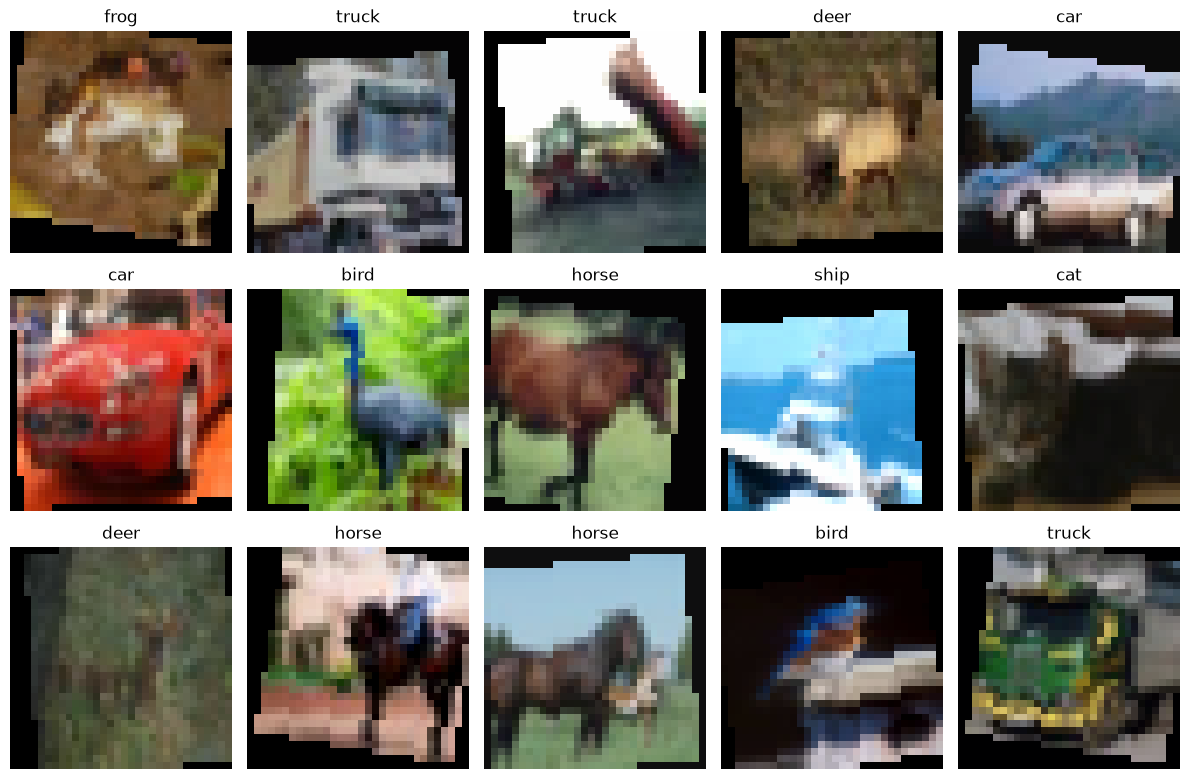

In [48]:
classes = ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    
    if torch.is_tensor(img):
        img = img.permute(1, 2, 0).numpy()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = img * std + mean
    img = np.clip(img, 0, 1)
    
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # this changes the device being used for calculations, since i have a nvidia gpu cuda will serve as a service to make use of the gpu
print(f"Device {device}")

Device cuda


In [50]:
class CIFAR10Classifier(nn.Module):
    def __init__(self, filters=[3,64,128,256], layers=[128], image_width=32, output=10, kernel_size=3, padding=1, pooling=2, dropout_rate=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=filters[0],
            out_channels=filters[1],
            kernel_size=kernel_size,
            padding=padding
        )
        self.batchnorm1 = nn.BatchNorm2d(filters[1])
        self.pool1 = nn.MaxPool2d(pooling, pooling)
        image_width //= pooling

        self.conv2 = nn.Conv2d(
            in_channels=filters[1],
            out_channels=filters[2],
            kernel_size=kernel_size,
            padding=padding
        )
        self.batchnorm2 = nn.BatchNorm2d(filters[2])
        self.pool2 = nn.MaxPool2d(pooling, pooling)
        image_width //= pooling

        self.conv3 = nn.Conv2d(
            in_channels=filters[2],
            out_channels=filters[3],
            kernel_size=kernel_size,
            padding=padding
        )
        self.batchnorm3 = nn.BatchNorm2d(filters[3])
        self.pool3 = nn.MaxPool2d(pooling, pooling)
        image_width //= pooling

        self.fc1 = nn.Linear(filters[3] * image_width**2, layers[0])
        self.fc2 = nn.Linear(layers[0], output)

        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [51]:
model = CIFAR10Classifier().to(device)

Epoch 1, Loss 1.8399
Epoch 2, Loss 1.5524
Epoch 3, Loss 1.4147
Epoch 4, Loss 1.3327
Epoch 5, Loss 1.2694
Epoch 6, Loss 1.2170
Epoch 7, Loss 1.1902
Epoch 8, Loss 1.1601
Epoch 9, Loss 1.1357
Epoch 10, Loss 1.1170
Epoch 11, Loss 1.1019
Epoch 12, Loss 1.0850
Epoch 13, Loss 1.0676
Epoch 14, Loss 1.0544
Epoch 15, Loss 1.0479
Epoch 16, Loss 1.0298
Epoch 17, Loss 1.0240
Epoch 18, Loss 1.0104
Epoch 19, Loss 1.0067
Epoch 20, Loss 0.9979
Epoch 21, Loss 0.9881
Epoch 22, Loss 0.9789
Epoch 23, Loss 0.9739
Epoch 24, Loss 0.9729
Epoch 25, Loss 0.9619
Epoch 26, Loss 0.9545
Epoch 27, Loss 0.9522
Epoch 28, Loss 0.9489
Epoch 29, Loss 0.9440
Epoch 30, Loss 0.9386
Epoch 31, Loss 0.9294
Epoch 32, Loss 0.9266
Epoch 33, Loss 0.9232
Epoch 34, Loss 0.9177
Epoch 35, Loss 0.9151
Epoch 36, Loss 0.9100
Epoch 37, Loss 0.9032
Epoch 38, Loss 0.9035
Epoch 39, Loss 0.8983
Epoch 40, Loss 0.8955
Epoch 41, Loss 0.8900
Epoch 42, Loss 0.8878
Epoch 43, Loss 0.8854
Epoch 44, Loss 0.8810
Epoch 45, Loss 0.8755
Epoch 46, Loss 0.87

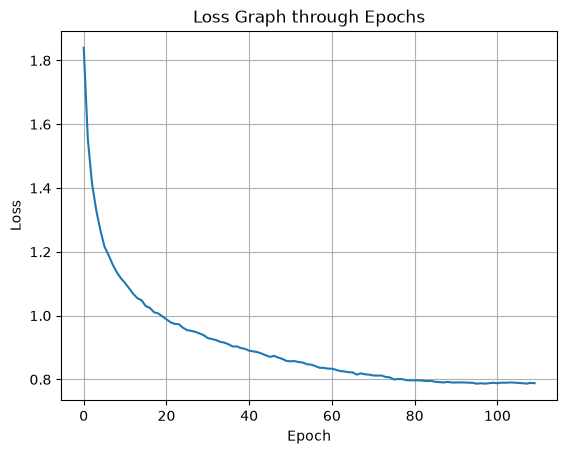

In [52]:
lf = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 110

train_losses = []

scheduler = CosineAnnealingLR(optimizer, T_max=100)

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = lf(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}, Loss {avg_loss:.4f}")

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Graph through Epochs")
plt.grid(True)
plt.show()

In [53]:
def eval(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

acc = eval(model, test_loader)
print(f"Accuracy {acc*100:.2f}%")

Accuracy 87.25%


In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()